In [1]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
import numpy as np
import matplotlib.pyplot as plt
from corner import corner
from getdist import plots
import scienceplots
import seaborn as sns
from scipy.stats import norm

import sys
sys.path.append("../")
from reconstruction_comparison import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_glamdring)
fdir = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity"

COLS = ['#006FED', '#E03424', 'gray', '#009966',
        '#000866', '#336600', '#006633', 'm', 'r']

## Definitions

In [2]:
def get_fname(simname, catalogue, sample_mag_dipole, zcmb_max=None, inference_method="bayes", no_Vext=None, verbose=True):
    """We read off the evidence in support of the dipole."""
    if zcmb_max is None:
        zcmb_max = 0.0500021

    sample_alpha = False if "no_field" in simname else True
    sample_beta = False if "no_field" in simname else None

    mag_dipole_prior_kind = "fixed" if sample_mag_dipole or zcmb_max == 0.055001 else None

    if sample_mag_dipole and no_Vext:
        print("Warning! Switching the inference method to Mike.")
        inference_method = "mike"
        mag_dipole_prior_kind = "fixed"

    return paths.flow_validation(
        fdir, simname, fdir_subfolder=None, catalogue=catalogue, inference_method=inference_method,
        sample_alpha=sample_alpha, sample_beta=sample_beta,
        no_Vext=no_Vext,
        sample_mag_dipole=sample_mag_dipole, dust_model=None,
        mag_dipole_prior_kind=mag_dipole_prior_kind,
        zcmb_max=zcmb_max, verbose_print=verbose,)


def read_dlogZ(simname, catalogue, zcmb_max=None, no_Vext=None, verbose=True):
    method = "mike"
    return get_gof("logZ_harmonic", get_fname(simname, catalogue, True, zcmb_max, method, no_Vext, verbose=verbose), ) - get_gof("logZ_harmonic", get_fname(simname, catalogue, False, zcmb_max, method, no_Vext, verbose=verbose), )


## Quick checks

In [3]:
# def get_fname(simname, catalogue, sample_mag_dipole):
#     """We read off the evidence in support of the dipole."""
#     # zcmb_max = 0.0750001 if "no_field" in simname else 0.0500021
#     zcmb_max = 0.0500021

#     sample_alpha = False if "no_field" in simname else True
#     sample_beta = False if "no_field" in simname else None

#     return paths.flow_validation(
#         fdir, simname, catalogue=catalogue, inference_method="mike",
#         sample_alpha=sample_alpha, sample_beta=sample_beta,
#         sample_mag_dipole=sample_mag_dipole, dust_model=None,
#         mag_dipole_prior_kind="fixed",
#         zcmb_max=zcmb_max)



# catalogue = ["CF4_TFR_i", "CF4_TFR_notSDSS_w1"]
catalogue = "CF4_TFR_w1"
# fname = get_fname("Carrick2015", catalogue, True)
fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_2MTF_simple_zcmb_max_0.05.hdf5"
# print("logZ = ", -get_gof("neg_lnZ_harmonic", fname) / np.log(10))
samples = get_some_samples(fname, ["Vext", "sigma_v", "e_mu", "eta_mean", "eta_std", "aTFR", "bTFR", "cTFR"])

In [10]:
from astropy.coordinates import SkyCoord, angular_separation
from astropy import units as u


def cartesian_to_radec(x, y, z, return_degrees=True, origin=[0., 0., 0.]):
    """
    Calculate the radial distance, RA [0, 360) deg and dec [-90, 90] deg.
    """
    x -= origin[0]
    y -= origin[1]
    z -= origin[2]

    d = (x**2 + y**2 + z**2)**0.5
    dec = np.arcsin(z / d)
    ra = np.arctan2(y, x)
    ra[ra < 0] += 2 * np.pi

    if return_degrees:
        ra *= 180 / np.pi
        dec *= 180 / np.pi

    # Place the origin back
    x += origin[0]
    y += origin[1]
    z += origin[2]

    return d, ra, dec


def radec_to_galactic(ra, dec):
    """
    Convert right ascension and declination to galactic coordinates (all in
    degrees.)
    """
    c = SkyCoord(ra=ra*u.degree, dec=dec*u.degree, frame='icrs')
    return c.galactic.l.degree, c.galactic.b.degree


def radec_cartesian_to_galactic(x, y, z, origin=[0., 0., 0.]):
    """
    Convert Cartesian coordinates in a frame where spherical coordinates
    correspond to RA/dec to galactic coordinates.
    """
    d, ra, dec = cartesian_to_radec(x, y, z, origin=origin)
    return d, *radec_to_galactic(ra, dec)

In [14]:
with File("clusters_LT-2.hdf5", 'r') as f:
    print(f["samples"].keys())
    bm = f["samples/bm"][...]

Vmag, l, b = radec_cartesian_to_galactic(bm[:, 2], bm[:, 0], bm[:, 1])

<KeysViewHDF5 ['a', 'b', 'bm', 'bm_boosted', 'logF_true', 'logT_true', 'mu', 'mu_logF', 'mu_logT', 'sigma_int', 'sigma_v', 'w_logF', 'w_logT']>


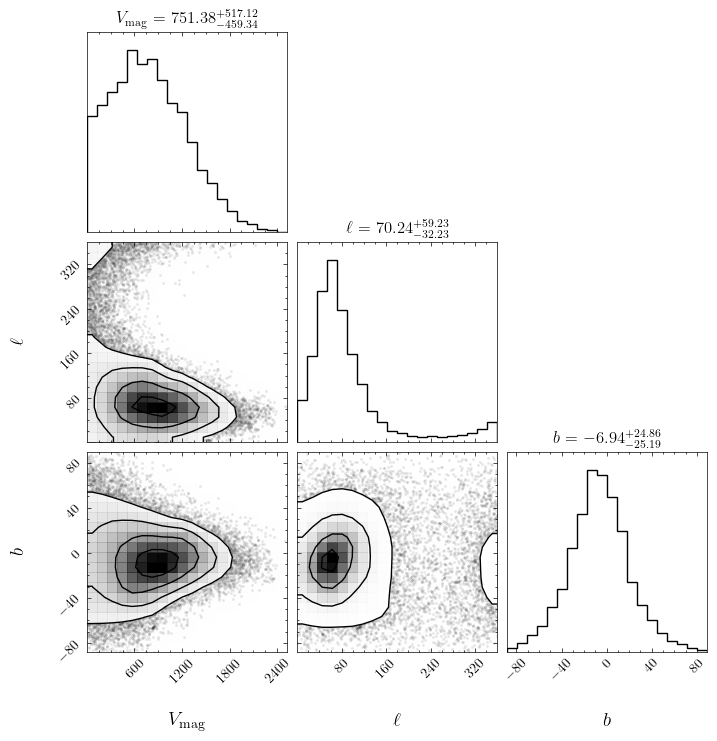

In [25]:
samples = np.array([Vmag, l, b]).T
labels = [r"$V_{\rm mag}$", r"$\ell$", r"$b$"]
keys = ["Vmag", "l", "b"]

with plt.style.context("science"):
    fig = corner(samples, labels=labels, show_titles=True,
             title_kwargs={"fontsize": 12}, smooth=1, label_kwargs={"fontsize": 14},)
    fig.savefig("corner.png", dpi=250)
    fig.show()

In [8]:
bm.shape

(30000, 3)

In [7]:
with File(fname, 'r') as f:
    print(f["samples"].keys())

<KeysViewHDF5 ['M_2MTF', 'Vext_cos_theta', 'Vext_mag', 'Vext_phi', 'aTFR_2MTF', 'bTFR_2MTF', 'beta', 'cTFR_2MTF', 'e_mu_2MTF', 'eta_2MTF', 'eta_mean_2MTF', 'eta_std_2MTF', 'sigma_v', 'xdir_Vext_skipZ', 'xdir_Vext_skipZ_normal']>


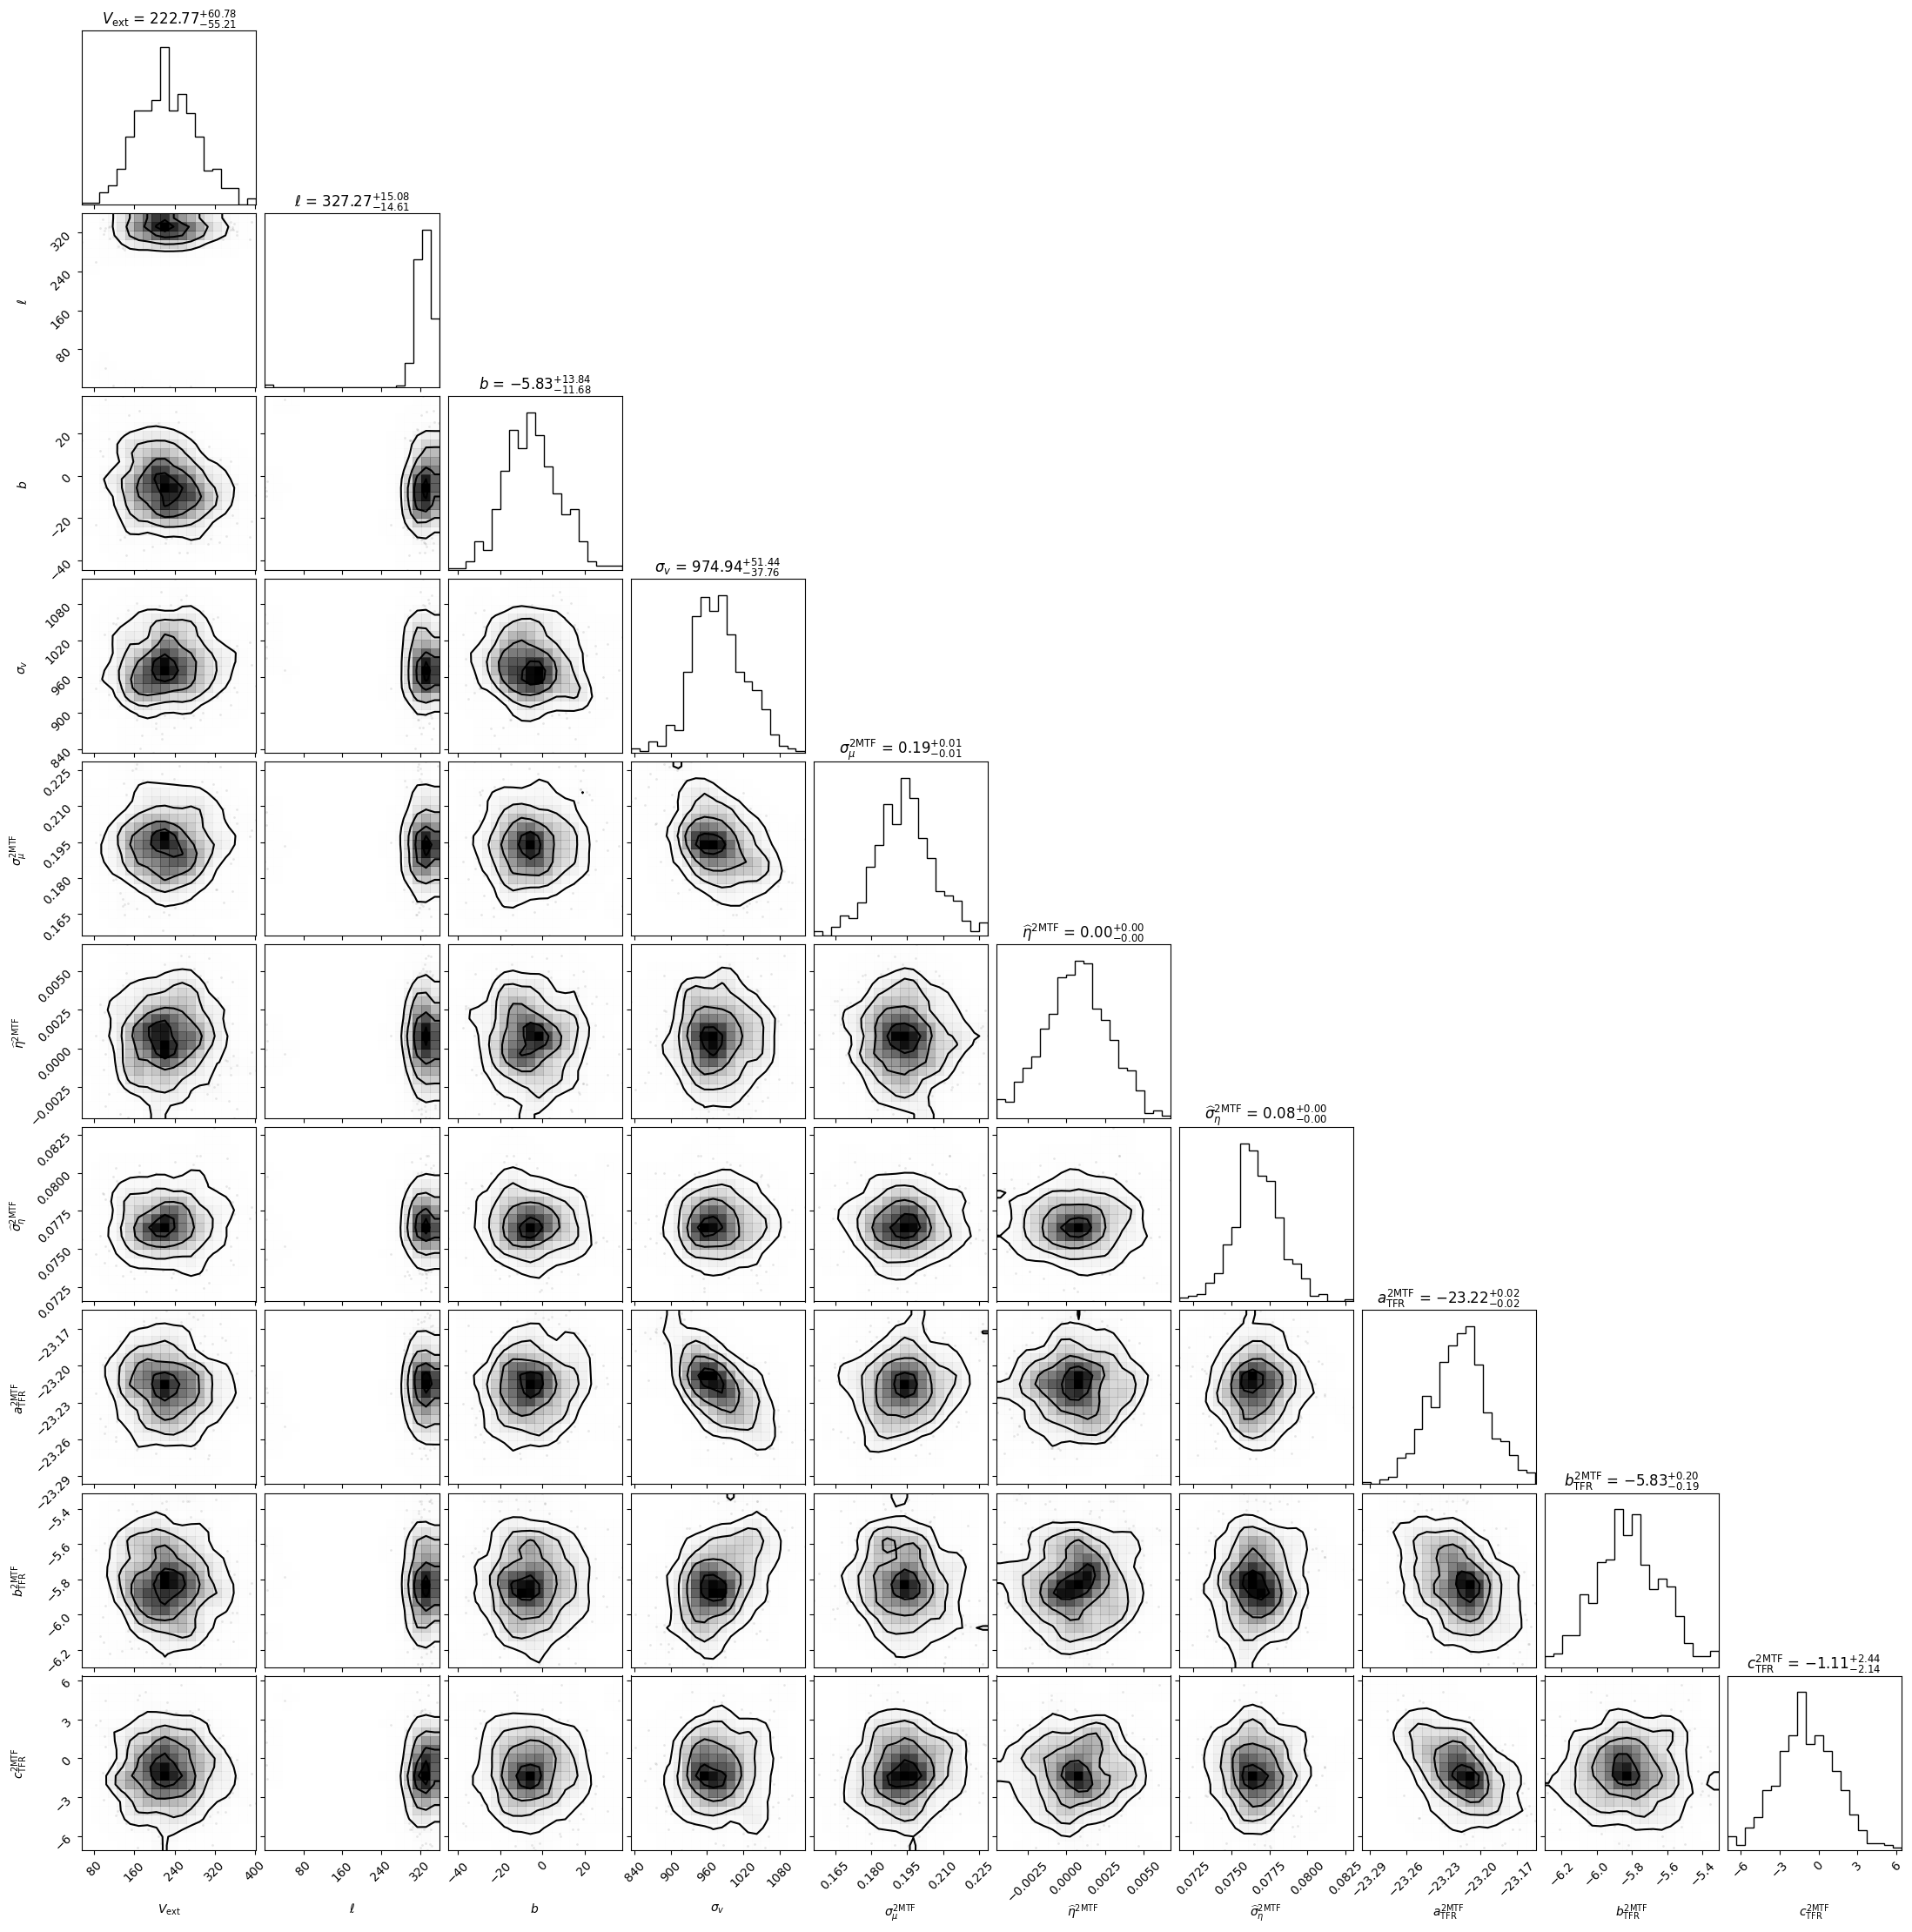

In [41]:
corner_samples, labels, keys = samples_for_corner(samples)

fig = corner(corner_samples, labels=labels, show_titles=True,
             title_kwargs={"fontsize": 12}, smooth=1)
# fig.savefig("../../../plots/corner.png", dpi=250)
fig.show()

## Data results



In [8]:
def get_samples_per_catalogue(catalogue, simnames, params, sample_mag_dipole):
    ranges = {
        "Vmag":[0, None],
        "sigma_v": [0, None],
        "mag_dipole_mag": [0, None],
        }


    X = []
    for simname in simnames:
        fname = get_fname(simname, catalogue, sample_mag_dipole)
        samples = get_some_samples(fname, params, )

        print(samples.keys())

        x = samples["mag_dipole_mag"]
        print(f"Dipole magnitude in {simname}: {np.mean(x):.4f} +/- {np.std(x):.4f}")

        X.append(samples_to_getdist(samples, simname_to_pretty(simname), ranges=ranges))
    return X


catalogue = "CF4_TFR_w1"
X = get_samples_per_catalogue(
    catalogue, ["Carrick2015", "no_field_400"],
    ["Vext", "mag_dipole", "sigma_v", "aTFR", "bTFR", "cTFR", "e_mu", "alpha", "beta"],
    sample_mag_dipole=True)

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_CF4_TFR_w1_bayes_zcmb_max_0.0500021_sample_alpha_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 23/02/2025 08:00:17
dict_keys(['Vmag', 'l', 'b', 'mag_dipole_mag', 'mag_dipole_l', 'mag_dipole_b', 'sigma_v', 'aTFR_CF4_TFR_w1', 'bTFR_CF4_TFR_w1', 'cTFR_CF4_TFR_w1', 'e_mu_CF4_TFR_w1', 'alpha_CF4_TFR_w1', 'beta'])
Dipole magnitude in Carrick2015: 0.0677 +/- 0.0256
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_no_field_400_CF4_TFR_w1_bayes_zcmb_max_0.0500021_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 23/02/2025 10:24:09
dict_keys(['Vmag', 'l', 'b', 'mag_dipole_mag', 'mag_dipole_l', 'mag_dipole_b', 'sigma_v', 'aTFR_CF4_TFR_w1', 'bTFR_CF4_TFR_w1', 'cTFR_CF4_TFR_w1', 'e_mu_CF4_TFR_w1'])
Dipole magnitude in no_field_400: 0.0992 +/- 0.0252
Removed no burn in


/tmp/ipykernel_3753959/3181664014.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.gcf().tight_layout()


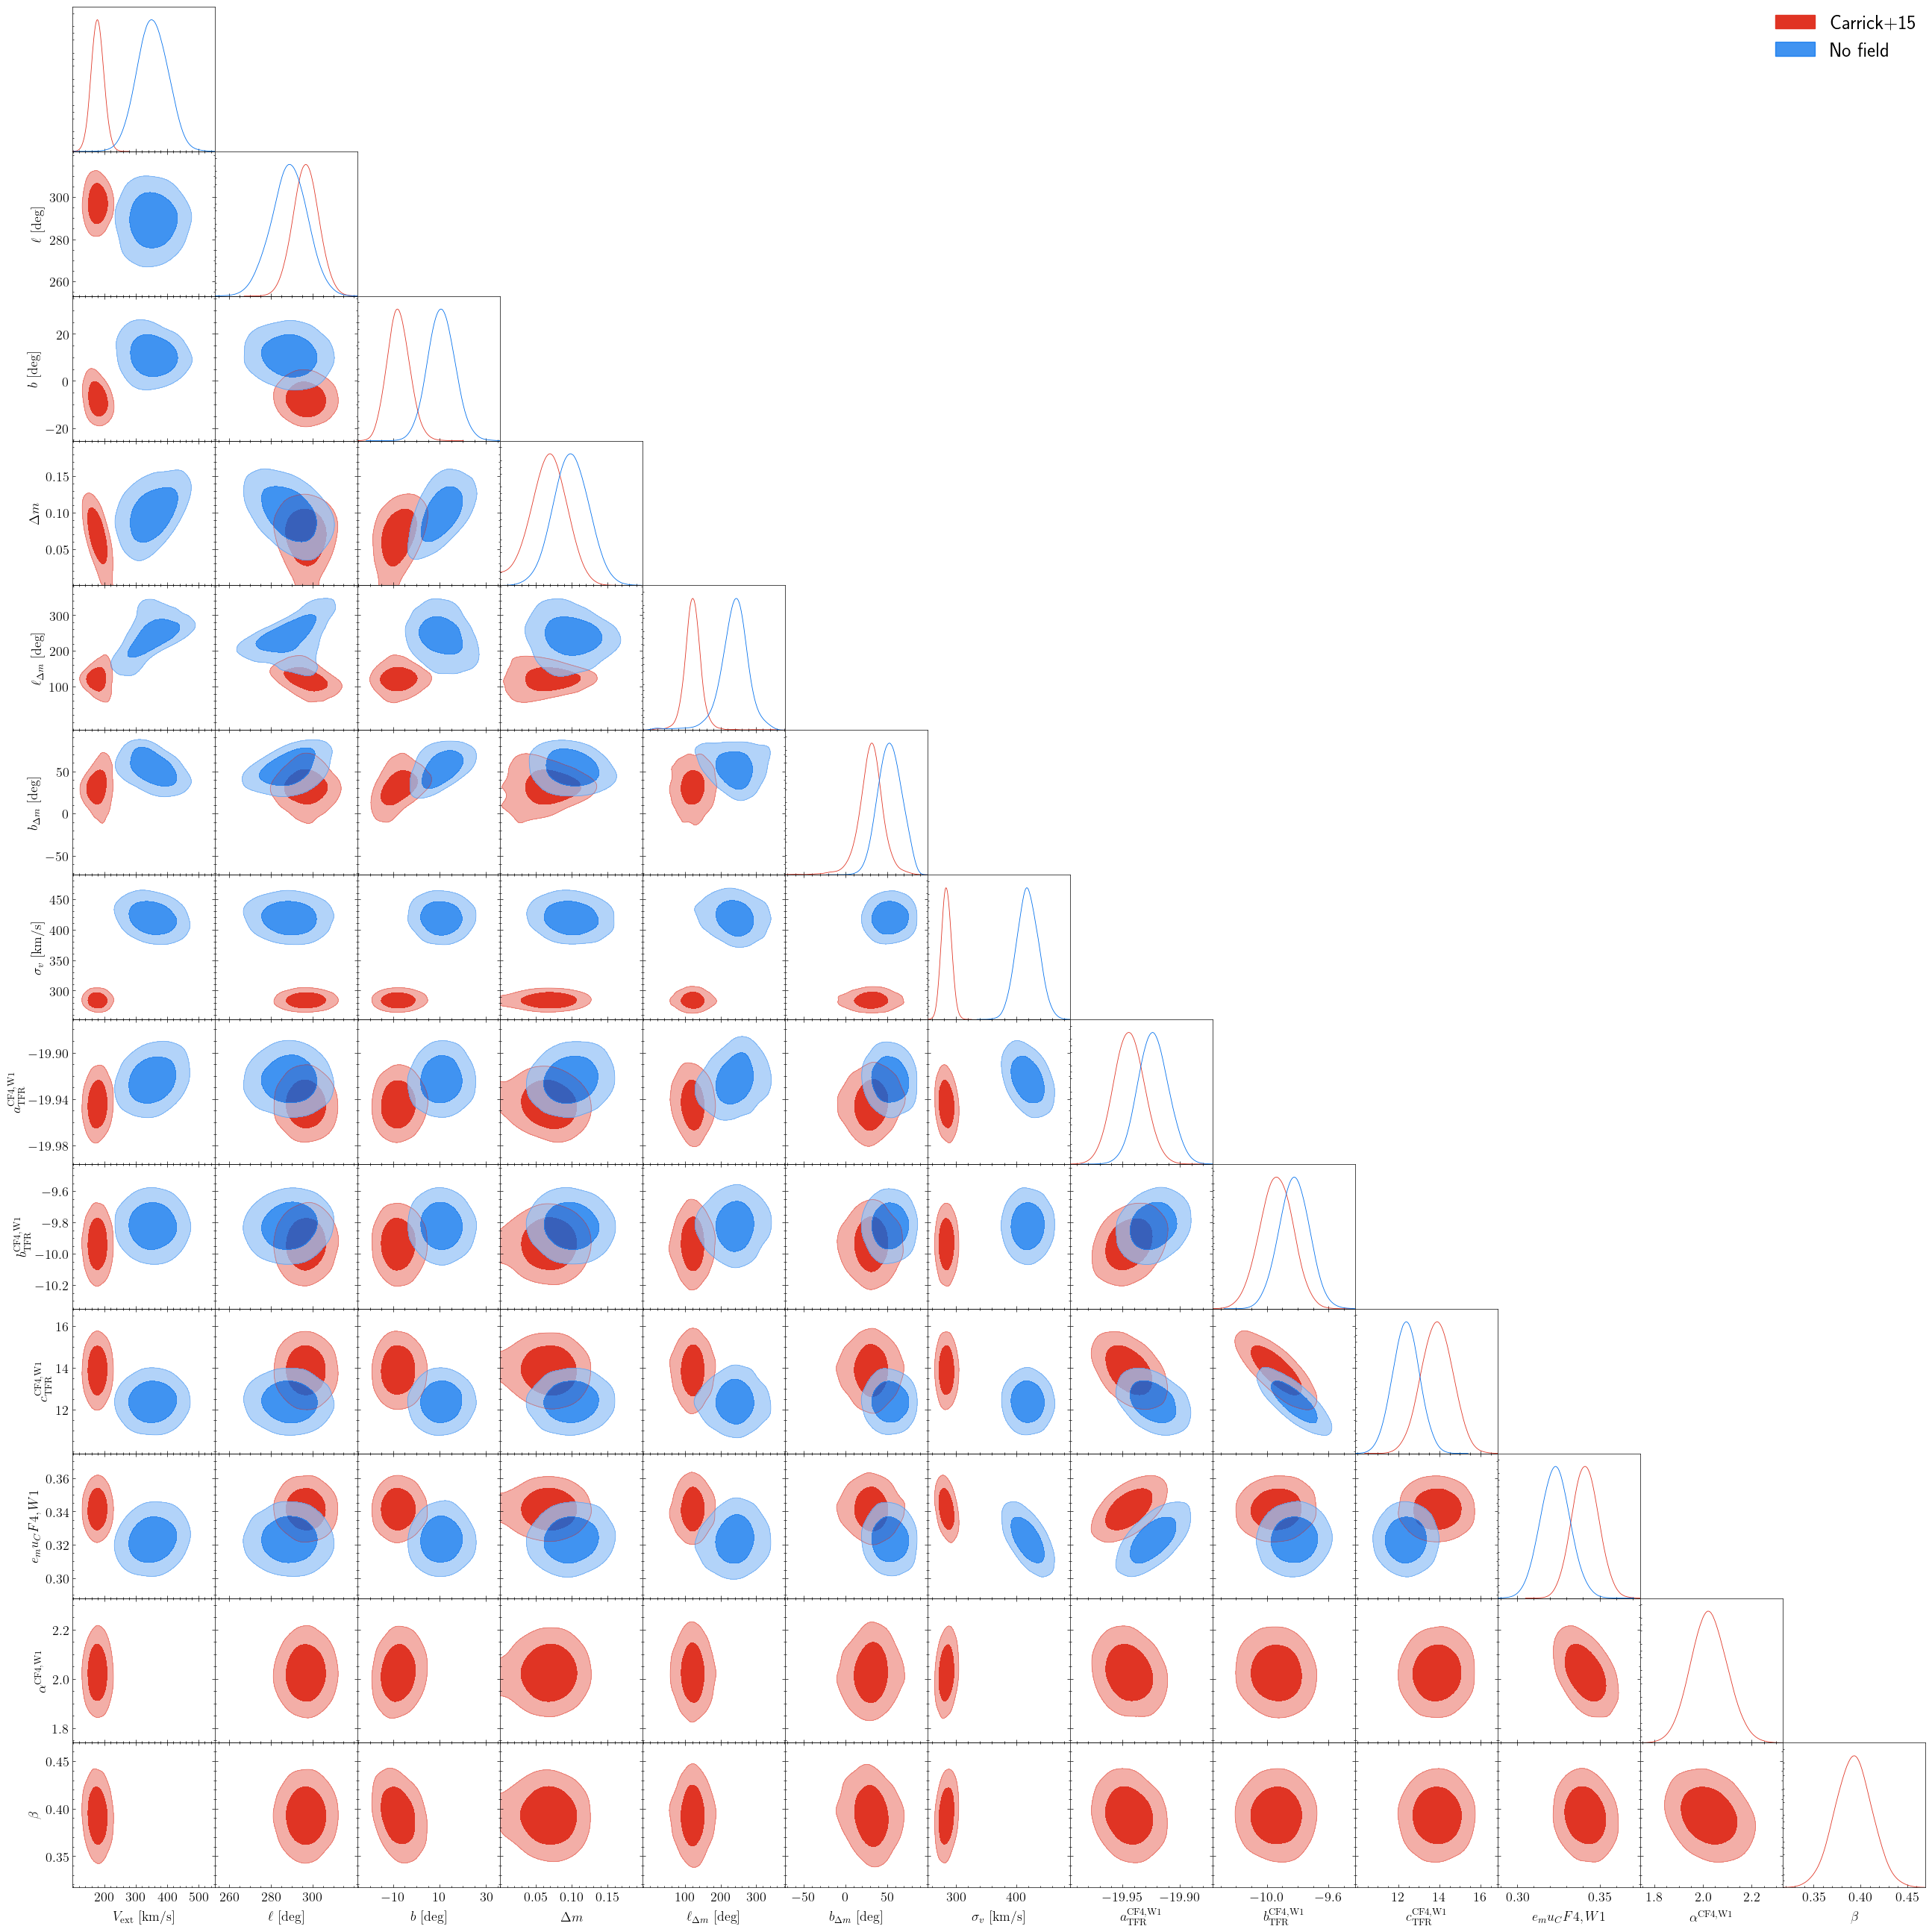

In [12]:
with plt.style.context('science'):
    g = plots.get_subplot_plotter()
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.75
    g.settings.legend_fontsize = 22
    g.settings.axes_labelsize = 16
    g.settings.axes_fontsize = 16

    g.triangle_plot(X, filled=True, legend_loc='upper right')

    plt.gcf().tight_layout()
    plt.gcf().savefig(f"../../../plots/full_posterior_{catalogue}.pdf", dpi=450, bbox_inches='tight')
    plt.gcf().show()

### Evidence comparison

In [10]:
catalogues = ["SFI_gals", "2MTF", "CF4_TFR_w1", "CF4_TFR_w2",
              # ["CF4_TFR_i", "CF4_TFR_notSDSS_w1"],
              ]

logB_no_field = np.asarray([read_dlogZ("no_field_400", catalogue) for catalogue in catalogues])
logB_carrick = np.asarray([read_dlogZ("Carrick2015", catalogue) for catalogue in catalogues])

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_no_field_400_SFI_gals_mike_zcmb_max_0.0500021_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 23/02/2025 08:27:22
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_no_field_400_SFI_gals_mike_zcmb_max_0.0500021.hdf5
Last modified: 24/02/2025 23:45:18
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_no_field_400_2MTF_mike_zcmb_max_0.0500021_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 23/02/2025 08:43:00
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_no_field_400_2MTF_mike_zcmb_max_0.0500021.hdf5
Last modified: 24/02/2025 23:53:34
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_no_field_400_CF4_TFR_w1_mike_zcmb_max_0.0500021_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 23/

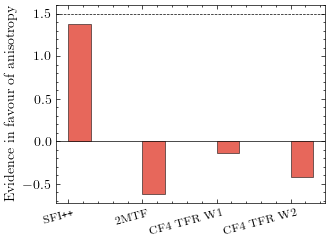

In [14]:
import matplotlib.transforms as mtransforms

x = np.arange(len(catalogues))
width = 0.3

with plt.style.context("science"):
    lw_ax = plt.rcParams["axes.linewidth"]
    fig, ax = plt.subplots()

    # ax.bar(x - width/2, logB_no_field, width=width,
    #        label=simname_to_pretty("no_field_400"), color=COLS[0], alpha=0.75,
    #        edgecolor="black", linewidth=0.5)
    ax.bar(x + width/2, logB_carrick, width=width,
            label=simname_to_pretty("Carrick2015"), color=COLS[1], alpha=0.75,
            edgecolor="black", linewidth=0.5)

    # ax.set_ylabel(r"$\log \mathcal{B}$ in favour of anisotropy")
    ax.set_ylabel(r"Evidence in favour of anisotropy")
    ax.set_xticks(ticks=x, labels=[catalogue_to_pretty(c) for c in catalogues],
               rotation=45, fontsize="small")

    ax.set_xticks(x, [catalogue_to_pretty(c) for c in catalogues], rotation=15,
                  ha="right")
    offset = mtransforms.ScaledTranslation(5 / 72, 0, fig.dpi_scale_trans)
    for label in ax.get_xticklabels():
        label.set_transform(label.get_transform() + offset)


    ax.axhline(0, color="black", linewidth=lw_ax, zorder=0)
    ax.axhline(1.5, color="black", linestyle="dashed", linewidth=lw_ax,
               zorder=0)

    # plt.legend(ncols=2)
    # plt.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, 1.2))
    plt.tight_layout()

    # plt.savefig("../../../plots/logB_data.pdf", dpi=450)
    plt.savefig("logB_data.png", dpi=450)
    plt.show()



### Posterior per simulation

In [28]:
def get_samples_per_catalogue(catalogue, simnames, params, sample_mag_dipole):
    ranges = {
        "Vmag":[0, None],
        "sigma_v": [0, None],
        "mag_dipole_mag": [0, None],
        }


    X = []
    for simname in simnames:
        fname = get_fname(simname, catalogue, sample_mag_dipole)
        samples = get_some_samples(fname, params, )

        x = samples["mag_dipole_mag"]
        print(f"Dipole magnitude in {simname}: {np.mean(x):.4f} +/- {np.std(x):.4f}")

        X.append(samples_to_getdist(samples, simname_to_pretty(simname), ranges=ranges))
    return X


catalogue = "CF4_TFR_w1"
X = get_samples_per_catalogue(
    catalogue, ["Carrick2015", "no_field_400"],
    ["Vext", "sigma_v", "mag_dipole"],
    sample_mag_dipole=True)

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_CF4_TFR_w1_bayes_zcmb_max_0.0500021_sample_alpha_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 23/02/2025 08:00:17
Dipole magnitude in Carrick2015: 0.0677 +/- 0.0256
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_no_field_400_CF4_TFR_w1_bayes_zcmb_max_0.0500021_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 23/02/2025 10:24:09
Dipole magnitude in no_field_400: 0.0992 +/- 0.0252
Removed no burn in


/tmp/ipykernel_2477968/3798489116.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.gcf().tight_layout()


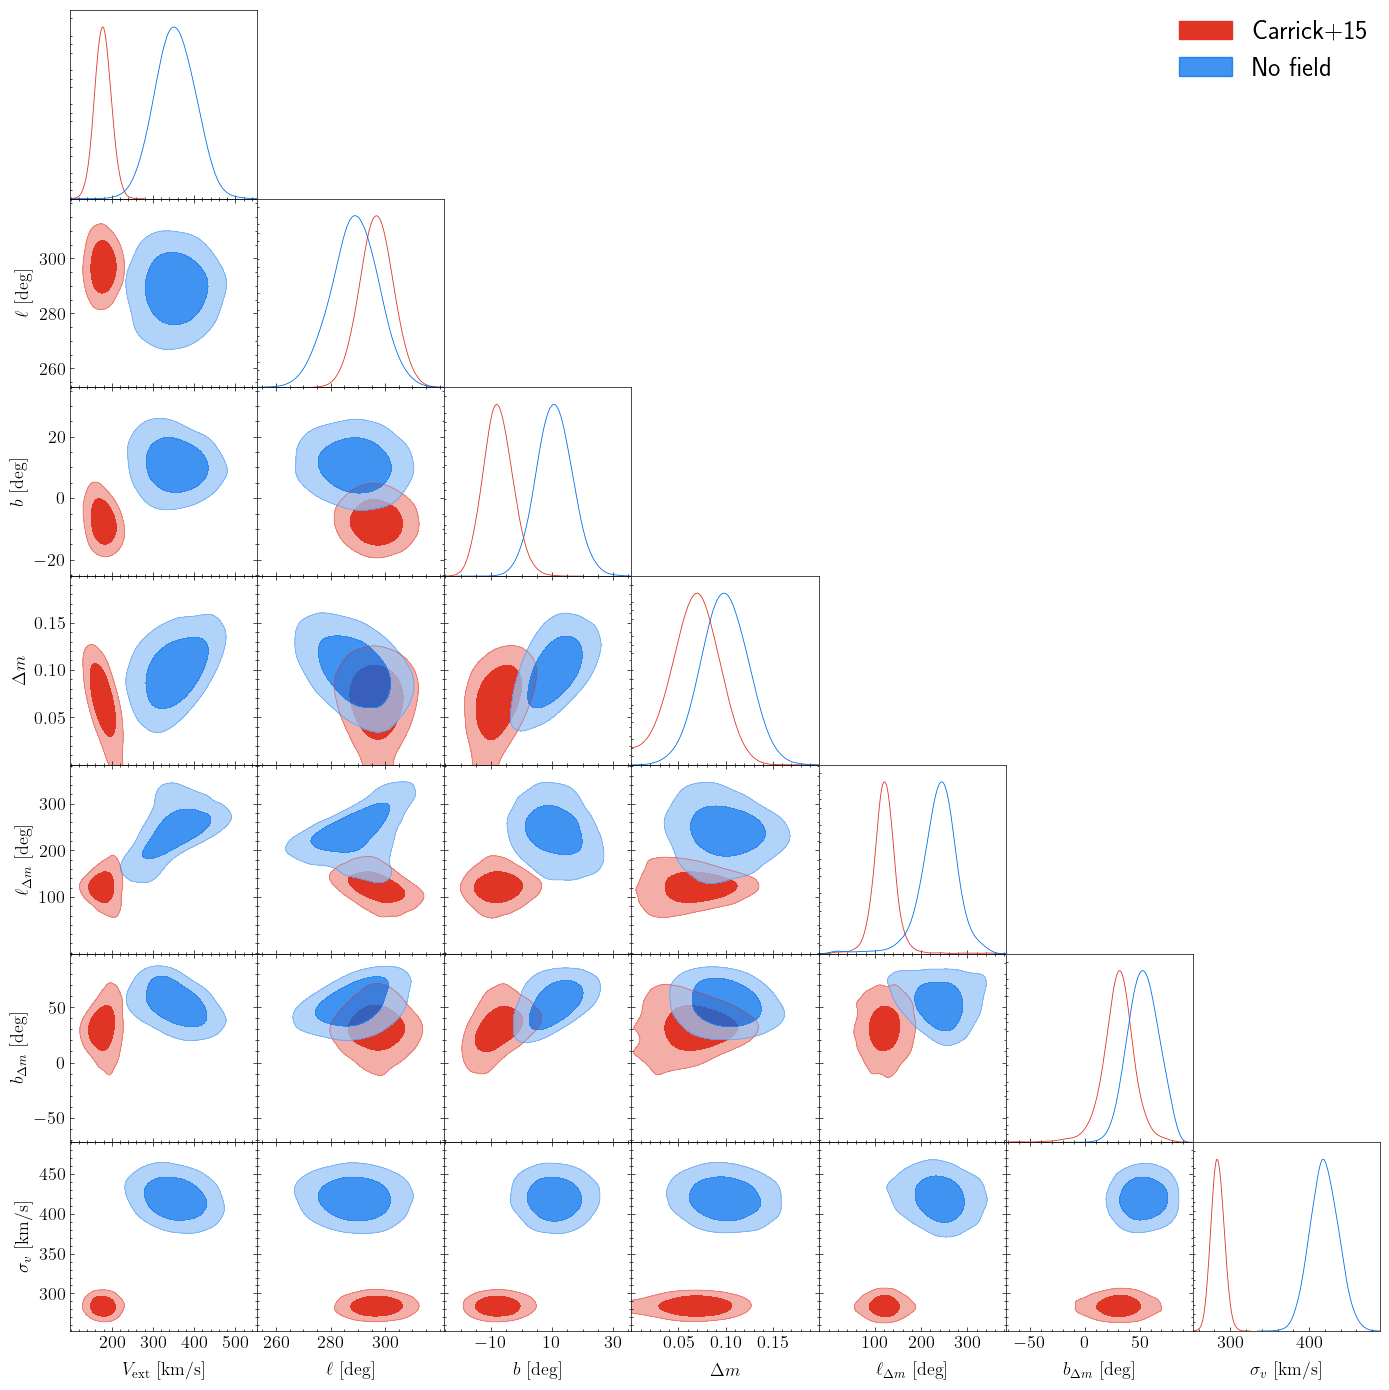

In [29]:
with plt.style.context('science'):
    g = plots.get_subplot_plotter()
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.75
    g.settings.legend_fontsize = 22
    g.settings.axes_labelsize = 16
    g.settings.axes_fontsize = 16

    g.triangle_plot(X, filled=True, legend_loc='upper right')

    plt.gcf().tight_layout()
    plt.gcf().savefig(f"../../../plots/posterior_per_catalogue_{catalogue}.pdf", dpi=450, bbox_inches='tight')
    plt.gcf().show()


### Posterior per catalogue

In [17]:
def get_samples_per_simname(catalogues, simname, params, sample_mag_dipole):
    ranges = {
        "Vmag":[0, None],
        "sigma_v": [0, None],
        "mag_dipole_mag": [0, None],
        }

    X = []
    for catalogue in catalogues:
        fname = get_fname(simname, catalogue, sample_mag_dipole)
        samples = get_some_samples(fname, params, )

        x = samples["mag_dipole_mag"]
        print(f"Dipole magnitude in {catalogue}: {np.mean(x):.4f} +/- {np.std(x):.4f}")

        X.append(samples_to_getdist(samples, catalogue_to_pretty(catalogue), ranges=ranges))
    return X



simname = "Carrick2015"
X = get_samples_per_simname(
    # ["CF4_TFR_w1", "CF4_TFR_w2"],
    ["SFI_gals", "2MTF", "CF4_TFR_w1",],
    simname, ["mag_dipole"], sample_mag_dipole=True)

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_SFI_gals_bayes_zcmb_max_0.0500021_sample_alpha_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 23/02/2025 07:16:54
Dipole magnitude in SFI_gals: 0.0527 +/- 0.0181
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_2MTF_bayes_zcmb_max_0.0500021_sample_alpha_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 23/02/2025 13:28:39
Dipole magnitude in 2MTF: 0.0341 +/- 0.0246
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_CF4_TFR_w1_bayes_zcmb_max_0.0500021_sample_alpha_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 23/02/2025 08:00:17
Dipole magnitude in CF4_TFR_w1: 0.0677 +/- 0.0256
Removed no burn in


/tmp/ipykernel_2874588/530623653.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.gcf().tight_layout()


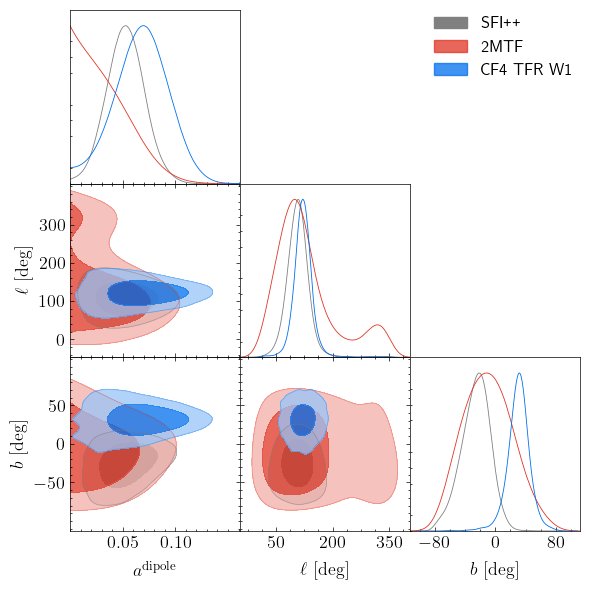

In [20]:
with plt.style.context('science'):
    g = plots.get_subplot_plotter()
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.75
    g.settings.legend_fontsize = 15
    g.settings.axes_labelsize = 16
    g.settings.axes_fontsize = 16

    g.triangle_plot(X, filled=True, legend_loc='upper right')

    plt.gcf().tight_layout()
    # plt.gcf().savefig(f"../../../plots/posterior_per_simulation_{simname}.pdf", dpi=300, bbox_inches='tight')
    plt.gcf().savefig(f"posterior_per_simulation_{simname}.png", dpi=300, bbox_inches='tight')
    plt.gcf().show()

### Posterior with and without the magnitude dipole

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_CF4_TFR_w1_bayes_zcmb_max_0.0500021_sample_alpha_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 23/02/2025 08:00:17
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_CF4_TFR_w1_bayes_zcmb_max_0.0500021_sample_alpha.hdf5
Last modified: 25/02/2025 03:13:51
Removed no burn in


/tmp/ipykernel_2477968/2419594624.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.gcf().tight_layout()


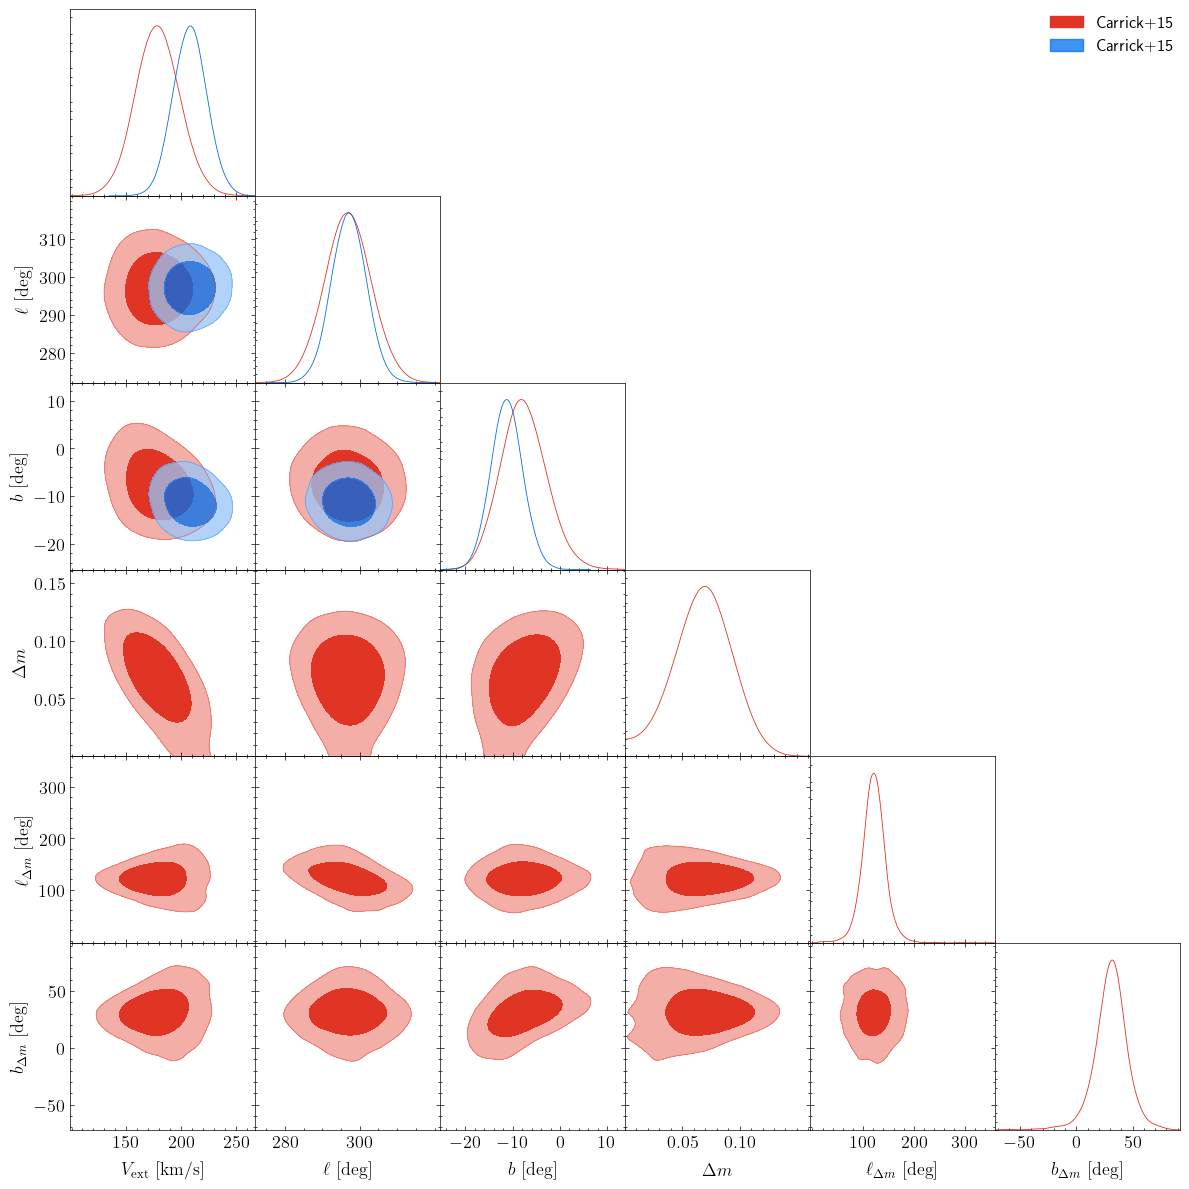

In [38]:
X = []
ranges = {
    "Vmag":[0, None],
    "mag_dipole_mag": [0, None],
    }


for sample_mag_dipole in [True, False]:
    fname = get_fname("Carrick2015", "CF4_TFR_w1", sample_mag_dipole)
    samples = ["Vext",]
    if sample_mag_dipole:
        samples.append("mag_dipole")
    
    samples = get_some_samples(fname, samples)

    Xi = samples_to_getdist(
        samples, simname_to_pretty("Carrick2015"), ranges=ranges)
    X.append(Xi)




with plt.style.context('science'):
    g = plots.get_subplot_plotter()
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.75
    g.settings.legend_fontsize = 15
    g.settings.axes_labelsize = 16
    g.settings.axes_fontsize = 16

    g.triangle_plot(X, filled=True, legend_loc='upper right')

    plt.gcf().tight_layout()
    # plt.gcf().savefig(f"../../../plots/posterior_per_simulation_{simname}.pdf", dpi=300, bbox_inches='tight')
    plt.gcf().show()

## How does the posterior change if ...

In [19]:
X = []
ranges = {
    "Vmag":[0, None],
    "mag_dipole_mag": [0, None],
    }


fname = get_fname("Carrick2015", "CF4_TFR_w1", sample_mag_dipole=True)
samples = get_some_samples(fname, ["Vext", "mag_dipole",])
X.append(samples_to_getdist(samples, "joint", ranges=ranges))


fname = get_fname("Carrick2015", "CF4_TFR_w1", sample_mag_dipole=False, )
samples = get_some_samples(fname, ["Vext",])
X.append(samples_to_getdist(samples, "Vext", ranges=ranges))

fname = get_fname("Carrick2015", "CF4_TFR_w1", sample_mag_dipole=True, no_Vext=True)
samples = get_some_samples(fname, ["mag_dipole",])
# samples = samples_to_getdist(samples, "mag_dip", ranges=ranges)
# X.append(samples)


with plt.style.context('science'):
    g = plots.get_subplot_plotter()
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.75
    g.settings.legend_fontsize = 15
    g.settings.axes_labelsize = 16
    g.settings.axes_fontsize = 16

    g.triangle_plot(X, filled=True, legend_loc='upper right', )

    plt.gcf().tight_layout()
    # plt.gcf().savefig(f"../../../plots/posterior_per_simulation_{simname}.pdf", dpi=300, bbox_inches='tight')
    plt.gcf().show()


File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_CF4_TFR_w1_bayes_zcmb_max_0.0500021_sample_alpha_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 23/02/2025 08:00:17
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_CF4_TFR_w1_bayes_zcmb_max_0.0500021_sample_alpha.hdf5
Last modified: 25/02/2025 03:13:51
Removed no burn in
Warning! Switching the inference method to Mike.
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_CF4_TFR_w1_mike_zcmb_max_0.0500021_sample_alpha_no_Vext_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 16/02/2025 22:48:15


KeyError: "Unable to synchronously open object (object 'mag_mag_dipole' doesn't exist)"

In [22]:
fname = get_fname("Carrick2015", "CF4_TFR_w1", sample_mag_dipole=True, no_Vext=True)

Warning! Switching the inference method to Mike.
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_CF4_TFR_w1_mike_zcmb_max_0.0500021_sample_alpha_no_Vext_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 16/02/2025 22:48:15


In [20]:
with File(fname) as f:
    print(f["samples"].keys())

<KeysViewHDF5 ['aTFR_CF4_TFR_w1', 'aTFR_dipole_CF4_TFR_w1_mag', 'alpha_CF4_TFR_w1', 'bTFR_CF4_TFR_w1', 'beta', 'cTFR_CF4_TFR_w1', 'cos_theta_aTFR_dipole_CF4_TFR_w1', 'e_mu_CF4_TFR_w1', 'phi_aTFR_dipole_CF4_TFR_w1', 'sigma_v']>


In [13]:
get_some_samples(fname, ["Vext", "mag_dipole",]).keys()

dict_keys(['Vmag', 'l', 'b', 'mag_dipole_mag', 'mag_dipole_l', 'mag_dipole_b'])

## Mock results

In [3]:
zcmb_max = 0.055001
mock_table = np.genfromtxt(f"/mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock_tables/Carrick2MTFmock_table_{zcmb_max}.txt")

dlogZ = np.full(len(mock_table), np.nan)

for n in range(len(mock_table)):
    try:
        dlogZ[n] = read_dlogZ("no_field_250", f"Carrick2MTFmock_{n}", zcmb_max=zcmb_max, verbose=False)
    except FileNotFoundError:
        pass

print(f"Found {np.sum(~np.isnan(dlogZ))} out of {len(dlogZ)}")

Found 65 out of 100


[1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.]
[3111. 3111. 3111. 3111. 3111. 3111. 3111. 3111. 3111. 3111.]
[5222. 5222. 5222. 5222. 5222. 5222. 5222. 5222. 5222. 5222.]
[7333. 7333. 7333. 7333. 7333. 7333. 7333. 7333. 7333. 7333.]
[9444. 9444. 9444. 9444. 9444. 9444. 9444. 9444. 9444. 9444.]
[11555. 11555. 11555. 11555. 11555. 11555. 11555. 11555. 11555. 11555.]
[13666. 13666. 13666. 13666. 13666. 13666. 13666. 13666. 13666. 13666.]


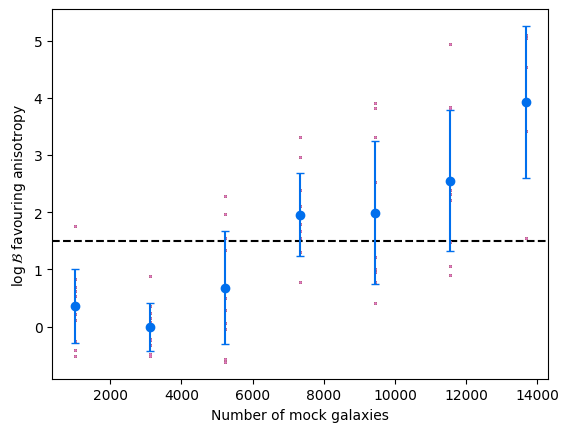

In [ ]:
lw = plt.rcParams["lines.linewidth"]


plt.figure()

for num_samples in np.unique(mock_table):
    m = mock_table == num_samples
    if np.sum(np.isfinite(dlogZ[m])) == 0:
        continue

    plt.scatter(mock_table, dlogZ, s=1)

    mean, std = np.nanmean(dlogZ[m]), np.nanstd(dlogZ[m])
    plt.errorbar(num_samples, mean, yerr=std, fmt="o", color=COLS[0],
                 label=f"{num_samples} samples", capsize=3)


plt.axhline(1.5, color="k", linestyle="--", zorder=0, lw=lw,)

plt.xlabel("Number of mock galaxies")
plt.ylabel(r"$\log \mathcal{B}$ favouring anisotropy")

plt.show()



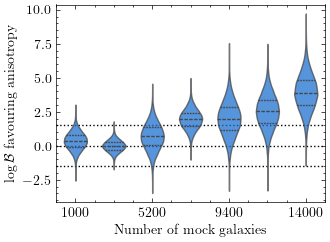

In [14]:
def format_sigfig(val, sig=2):
    if val < 1:
        # Use floating-point format for small numbers
        return f"{val:.2f}"
    elif val < 10:
        # Use one decimal for values less than 10
        return f"{val:.1f}"
    else:
        # Use integer format for larger numbers
        return f"{int(round(val, -int(np.floor(np.log10(abs(val))) - (sig - 1))))}"



with plt.style.context("science"):
    lw = plt.rcParams["lines.linewidth"]
    plt.figure()

    all_resamples = []
    all_positions = []

    # Resample and create custom violins
    for num_samples in np.unique(mock_table):
        m = mock_table == num_samples
        if np.sum(np.isfinite(dlogZ[m])) == 0:
            continue

        resampled_data = norm.rvs(
            loc=np.nanmean(dlogZ[m]), scale=np.nanstd(dlogZ[m]), size=100_000)
        all_resamples.extend(resampled_data)
        all_positions.extend([num_samples] * len(resampled_data))

    sns.violinplot(x=all_positions, y=all_resamples, inner="quart",
                   cut=0, density_norm="width", bw_method="scott",
                   width=0.6, color=COLS[0], alpha=0.75, linewidth=lw)

    for x in [-1.5, 0, 1.5]:
        plt.axhline(x, color="k", linestyle="dotted", zorder=0, lw=lw)

    plt.xlabel("Number of mock galaxies")
    plt.ylabel(r"$\log \mathcal{B}$ favouring anisotropy")

    plt.xticks(ticks=np.arange(0, len(np.unique(mock_table)), 2)[:-1],
               labels=[format_sigfig(val) for val in np.unique(mock_table)[::2]][:-1])

    plt.tight_layout()
    plt.savefig("../../../plots/logB_mock.pdf", dpi=450)

    plt.show()

